# Python Lesson 42: Linear Regression (Least Squares)

**Concept page:** `wiki/concepts/linear-regression.md` · **Area:** ml-connection

**You will be able to:**
- use the Cambodian closed-form formulas for a and b
- compare with gradient descent, NumPy and scikit-learn
- verify the line passes through the mean point

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Textbook formulas (Grade 12 basic p. 161–162)

In [2]:
def ls_line(x,y):
    x,y=np.array(x,float),np.array(y,float); n=len(x)
    a=(n*(x*y).sum()-x.sum()*y.sum())/(n*(x**2).sum()-x.sum()**2); b=(y.sum()-a*x.sum())/n
    return a,b
print(ls_line([1,1,2,4],[1,2,2,6]))      # (1.5, -0.25)
print(ls_line([1,2,3],[2,5,3]))          # Coursera example: (0.5, 7/3)

(np.float64(1.5), np.float64(-0.25))
(np.float64(0.5), np.float64(2.3333333333333335))


## 2. Other routes give the same answer

In [3]:
x=np.array([1,2,3.]); y=np.array([2,5,3.])
print(np.polyfit(x,y,1))
from sklearn.linear_model import LinearRegression
m=LinearRegression().fit(x[:,None],y); print(m.coef_,m.intercept_)
# gradient descent on E(m,b)
mm,bb=0.,0.
for _ in range(20000):
    gm=(2*(mm*x+bb-y)*x).sum(); gb=(2*(mm*x+bb-y)).sum(); mm-=0.01*gm/len(x); bb-=0.01*gb/len(x)
print(mm,bb)

[0.5    2.3333]


[0.5] 2.3333333333333344
0.5000000000000372 2.3333333333332478


## 3. Passes through the mean point; plot

True


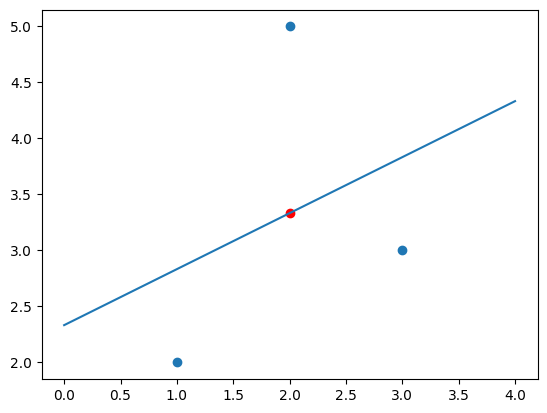

In [4]:
a,b=ls_line(x,y); print(np.isclose(a*x.mean()+b,y.mean()))
xs=np.linspace(0,4,50); plt.scatter(x,y); plt.plot(xs,a*xs+b); plt.scatter(x.mean(),y.mean(),c='r'); plt.show()

## 4. Normal equations in matrix form

In [5]:
X=np.c_[x,np.ones_like(x)]; print(np.linalg.solve(X.T@X,X.T@y))

[0.5    2.3333]


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 basic p. 162: points (1,1),(1,2),(2,2),(4,6) give y = 1.5x − 0.25.

In [6]:
print(ls_line([1,1,2,4],[1,2,2,6]))

(np.float64(1.5), np.float64(-0.25))


## Exercises

**Exercise 1.** Fit TV-style data: budgets [230.1,44.5,17.2,151.5,180.8] and sales [22.1,10.4,9.3,18.5,12.9]; report slope and intercept.

In [7]:
# your code here

**Exercise 2.** Show the residuals of the least-squares line sum to ~0.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
a,b=ls_line([230.1,44.5,17.2,151.5,180.8],[22.1,10.4,9.3,18.5,12.9]); print(a,b); assert a>0

0.05176182092143312 8.179089512586717


In [10]:
# Solution 2
x=np.array([1,2,3.]); y=np.array([2,5,3.]); a,b=ls_line(x,y); assert abs((y-(a*x+b)).sum())<1e-9